# 20 · Causal uplift — which patients benefit most from DBS (on pain)?

Standard prediction answers "will this patient worsen?"; we instead want the **individual treatment effect (ITE/CATE)** — the counterfactual difference between that patient's predicted Δ-pain *if treated with DBS* and *if not*. Methods:

- **T-learner** (two separate random forests; CATE = µ_DBS − µ_NoDBS).
- **Causal forest** (`grf::causal_forest`) — direct estimation of heterogeneous treatment effects.

Features include biomarker + genetic data from notebook 19. Outcomes: continuous Δ-pain and binary worsening.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2); library(purrr); library(forcats)
  library(randomForest); library(pROC); library(grf)
})
enriched <- readRDS(file.path(OUT_OBJ, "patient_anchor_features_enriched.rds"))
cat("n:", nrow(enriched), "  columns:", ncol(enriched), "\n")
cat("will_receive_dbs distribution:\n"); print(table(enriched$will_receive_dbs))

Warning message:
“package ‘grf’ was built under R version 4.5.2”


n: 642   columns: 40 


will_receive_dbs distribution:



FALSE  TRUE 
  575    67 


In [2]:
# Design matrix — demographics + pre-anchor trajectory features + biomarkers
median_impute <- function(x){ x[is.na(x)] <- stats::median(x, na.rm=TRUE); x }

feat_cols <- c(
  "age_at_visit","ageonset","duration_yrs","SEX","BMI",
  "LEDD","updrs3_score","NHY",
  "NP1DPRS","NP1ANXS","gds","stai","scopa",
  "pre_mean","pre_max","pre_sd","pre_last","pre_slope","pre_n",
  "mean_putamen","mean_caudate","con_putamen",
  "asyn","NFL_CSF","nfl_serum","abeta","tau","ptau","APOE_e4"
)
feat_cols <- intersect(feat_cols, names(enriched))
cat("Features used (", length(feat_cols), "):", paste(feat_cols, collapse=", "), "\n\n")

# Subgroup as one-hot (since there are several levels and most sporadic)
enriched2 <- enriched %>%
  dplyr::mutate(
    sg_LRRK2 = as.integer(grepl("LRRK2", subgroup)),
    sg_GBA   = as.integer(grepl("GBA", subgroup)),
    sg_SNCA  = as.integer(subgroup == "SNCA" & !is.na(subgroup))
  )
feat_cols <- c(feat_cols, "sg_LRRK2","sg_GBA","sg_SNCA")

X <- enriched2 %>% dplyr::select(dplyr::all_of(feat_cols)) %>%
  dplyr::mutate(dplyr::across(dplyr::everything(), median_impute)) %>% as.matrix()
W <- as.integer(enriched2$will_receive_dbs)    # treatment
Y_cont <- enriched2$delta                      # continuous outcome (Δ pain)
Y_bin  <- as.integer(enriched2$delta < 1)      # no-worsening
cat("Design:", nrow(X), "x", ncol(X), "  N treated (DBS):", sum(W), "  N control:", sum(1-W), "\n")

Features used ( 29 ): age_at_visit, ageonset, duration_yrs, SEX, BMI, LEDD, updrs3_score, NHY, NP1DPRS, NP1ANXS, gds, stai, scopa, pre_mean, pre_max, pre_sd, pre_last, pre_slope, pre_n, mean_putamen, mean_caudate, con_putamen, asyn, NFL_CSF, nfl_serum, abeta, tau, ptau, APOE_e4 



Design: 642 x 32   N treated (DBS): 67   N control: 575 


In [3]:
# T-learner on continuous Δ pain
set.seed(42)
m_dbs  <- randomForest::randomForest(x = X[W == 1, , drop = FALSE], y = Y_cont[W == 1],
                                     ntree = 1000)
m_nodb <- randomForest::randomForest(x = X[W == 0, , drop = FALSE], y = Y_cont[W == 0],
                                     ntree = 1000)
mu_dbs  <- predict(m_dbs,  newdata = X)
mu_nodb <- predict(m_nodb, newdata = X)
cate_T <- mu_dbs - mu_nodb  # negative = DBS reduces pain vs counterfactual no-DBS

# Summary of CATE
summary(cate_T)
quantile(cate_T, probs = c(0.1, 0.25, 0.5, 0.75, 0.9))

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
-2.419891 -0.315190 -0.015258 -0.009415  0.305321  2.196449 

10%         25%         50%         75%         90% 
-0.68527399 -0.31519030 -0.01525804  0.30532083  0.69461783

In [4]:
# Causal forest — more principled CATE estimation
set.seed(42)
cf <- grf::causal_forest(X = X, Y = Y_cont, W = W, num.trees = 2000, honesty = TRUE)
cate_CF <- predict(cf)$predictions
cat("Causal-forest CATE summary:\n"); print(summary(cate_CF))

# Variable importance (out of bag)
vi <- grf::variable_importance(cf)
vi_df <- tibble::tibble(feature = colnames(X), importance = as.numeric(vi)) %>%
  dplyr::arrange(dplyr::desc(importance))
print(vi_df, n = 30)
save_table(vi_df, "causal_forest_importance")

Causal-forest CATE summary:


      Min.    1st Qu.     Median       Mean    3rd Qu.       Max. 
-0.0703773  0.0004549  0.0264893  0.0483426  0.0777516  0.2952289 


# A tibble: 32 × 2
   feature      importance
   <chr>             <dbl>
 1 LEDD           0.190   
 2 ageonset       0.0901  
 3 pre_n          0.0554  
 4 duration_yrs   0.0534  
 5 scopa          0.0496  
 6 pre_sd         0.0434  
 7 updrs3_score   0.0413  
 8 ptau           0.0399  
 9 nfl_serum      0.0390  
10 pre_mean       0.0387  
11 mean_putamen   0.0369  
12 abeta          0.0330  
13 stai           0.0326  
14 pre_last       0.0308  
15 mean_caudate   0.0296  
16 gds            0.0267  
17 pre_slope      0.0242  
18 con_putamen    0.0241  
19 BMI            0.0225  
20 tau            0.0208  
21 asyn           0.0180  
22 age_at_visit   0.0148  
23 NFL_CSF        0.0128  
24 pre_max        0.00867 
25 sg_LRRK2       0.00589 
26 NP1DPRS        0.00544 
27 APOE_e4        0.00532 
28 NP1ANXS        0.00322 
29 SEX            0.00275 
30 NHY            0.000496
# ℹ 2 more rows


In [5]:
# Average treatment effect on the treated + heterogeneity test
ate <- grf::average_treatment_effect(cf)
cat(sprintf("ATE: %.3f (SE %.3f)\n", ate["estimate"], ate["std.err"]))

# Calibration test for heterogeneity
test_calib <- grf::test_calibration(cf)
print(test_calib)

Warning message in grf::average_treatment_effect(cf):
“Estimated treatment propensities go as low as 0.039 which means that treatment effects for some controls may not be well identified. In this case, using `target.sample=treated` may be helpful.”


ATE: 0.018 (SE 0.068)



Best linear fit using forest predictions (on held-out data)
as well as the mean forest prediction as regressors, along
with one-sided heteroskedasticity-robust (HC3) SEs:

                               Estimate Std. Error t value Pr(>t)
mean.forest.prediction           3.1207     3.2037  0.9741 0.1652
differential.forest.prediction  -2.0095     1.4645 -1.3722 0.9148



In [6]:
# Rank patients by CATE and compare top vs bottom decile on observed outcomes
pat <- tibble::tibble(
  PATNO = enriched2$PATNO,
  arm   = dplyr::if_else(W == 1, "DBS", "Never-DBS"),
  cate_T = cate_T,
  cate_CF = cate_CF,
  delta  = Y_cont,
  worsened = enriched2$worsened
)
pat <- pat %>% dplyr::mutate(
  decile_CF = dplyr::ntile(cate_CF, 10),
  responder_pred = dplyr::case_when(
    cate_CF <= stats::quantile(cate_CF, 0.2) ~ "Top-20% predicted responders",
    cate_CF >= stats::quantile(cate_CF, 0.8) ~ "Bottom-20% predicted (harm/no benefit)",
    TRUE                                      ~ "Middle 60%"
  )
)
summ_r <- pat %>% dplyr::group_by(responder_pred, arm) %>%
  dplyr::summarise(n = dplyr::n(), mean_delta = mean(delta, na.rm = TRUE),
                   pct_worsen = mean(worsened, na.rm = TRUE), .groups = "drop")
print(summ_r)
save_table(summ_r, "cate_responder_groups")
save_object(pat, "cate_per_patient")

# A tibble: 6 × 5
  responder_pred                         arm           n mean_delta pct_worsen
  <chr>                                  <chr>     <int>      <dbl>      <dbl>
1 Bottom-20% predicted (harm/no benefit) DBS          34     0.0512      0.176
2 Bottom-20% predicted (harm/no benefit) Never-DBS    95    -0.200       0.116
3 Middle 60%                             DBS          29    -0.0314      0.103
4 Middle 60%                             Never-DBS   355     0.0897      0.163
5 Top-20% predicted responders           DBS           4     0.875       0.5  
6 Top-20% predicted responders           Never-DBS   125     0.268       0.168


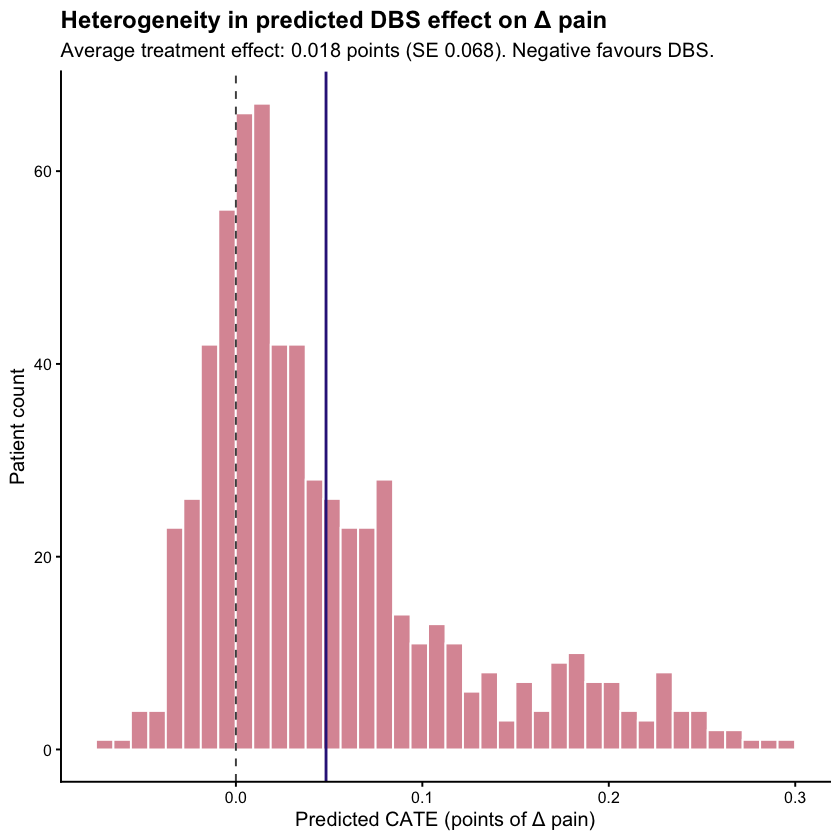

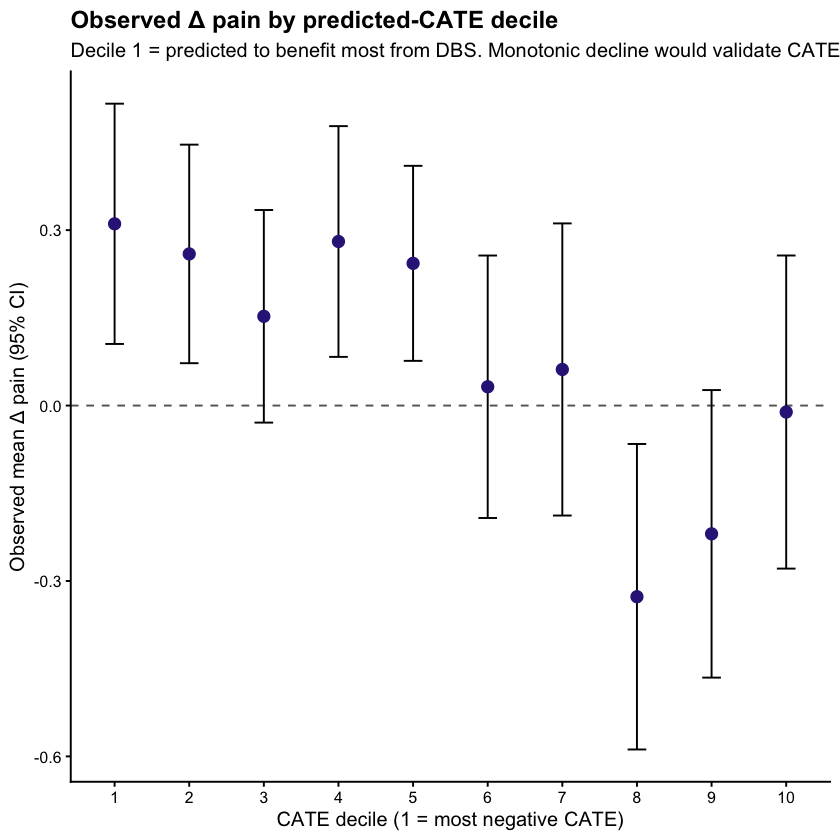

In [7]:
# Figure: CATE distribution and decile-wise observed Δ pain
p_hist <- ggplot(pat, aes(x = cate_CF)) +
  geom_histogram(bins = 40, fill = "#CC6677", alpha = 0.7, colour = "white") +
  geom_vline(xintercept = 0, linetype = "dashed", colour = "grey30") +
  geom_vline(xintercept = mean(cate_CF), colour = "#332288", linewidth = 0.8) +
  labs(title = "Heterogeneity in predicted DBS effect on Δ pain",
       subtitle = sprintf("Average treatment effect: %.3f points (SE %.3f). Negative favours DBS.", ate["estimate"], ate["std.err"]),
       x = "Predicted CATE (points of Δ pain)", y = "Patient count") +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold"))
p_hist
save_fig(p_hist, "Figure13_cate_distribution", width = 8, height = 4.4)

p_dec <- pat %>% dplyr::group_by(decile_CF) %>%
  dplyr::summarise(n = dplyr::n(), mean_delta = mean(delta, na.rm = TRUE),
                   se = stats::sd(delta, na.rm=TRUE)/sqrt(n), .groups = "drop") %>%
  dplyr::mutate(lo = mean_delta - 1.96*se, hi = mean_delta + 1.96*se)
p_dec_plot <- ggplot(p_dec, aes(decile_CF, mean_delta)) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey40") +
  geom_errorbar(aes(ymin = lo, ymax = hi), width = 0.25) +
  geom_point(size = 3, colour = "#332288") +
  scale_x_continuous(breaks = 1:10) +
  labs(title = "Observed Δ pain by predicted-CATE decile",
       subtitle = "Decile 1 = predicted to benefit most from DBS. Monotonic decline would validate CATE.",
       x = "CATE decile (1 = most negative CATE)", y = "Observed mean Δ pain (95% CI)") +
  theme_classic(base_size = 12) + theme(plot.title = element_text(face = "bold"))
p_dec_plot
save_fig(p_dec_plot, "Figure14_cate_decile_validation", width = 8, height = 4.4)

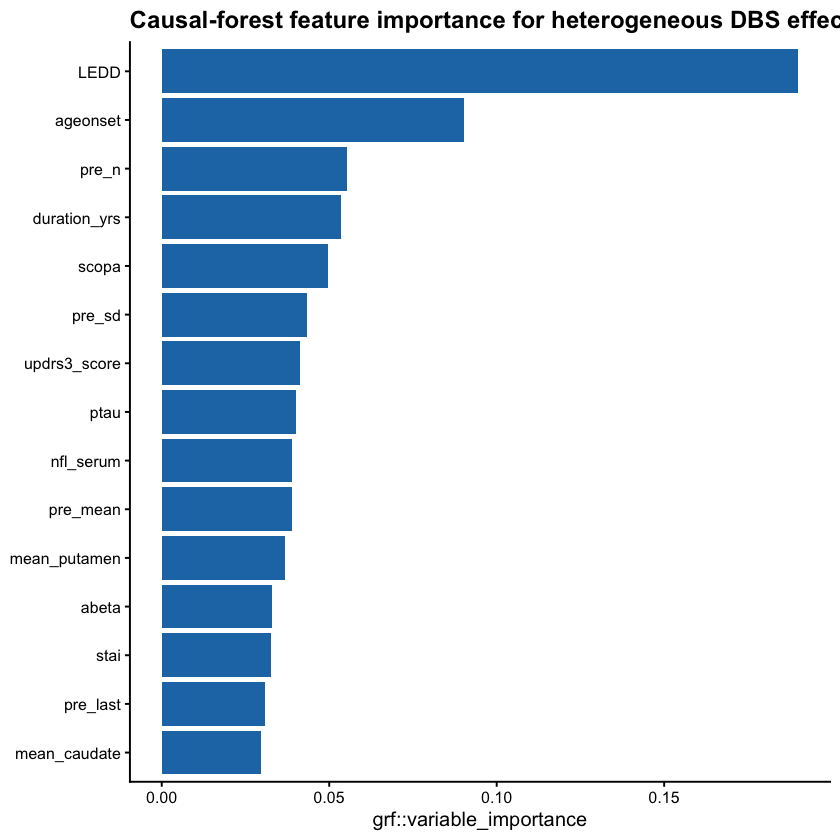

In [8]:
# Top predictors of heterogeneity: which features drive different CATEs?
p_vi <- ggplot(vi_df %>% dplyr::slice_head(n = 15) %>%
                 dplyr::mutate(feature = forcats::fct_reorder(feature, importance)),
               aes(importance, feature)) +
  geom_col(fill = "#1f78b4") +
  labs(title = "Causal-forest feature importance for heterogeneous DBS effect on pain",
       x = "grf::variable_importance", y = NULL) +
  theme_classic(base_size = 12) + theme(plot.title = element_text(face = "bold"))
p_vi
save_fig(p_vi, "Figure15_cate_feature_importance", width = 8, height = 5)

In [9]:
save_object(cf, "causal_forest_fit")
cat("Saved causal_forest_fit.rds. Key outputs: cate_per_patient.rds, causal_forest_importance.csv.\n")

Saved causal_forest_fit.rds. Key outputs: cate_per_patient.rds, causal_forest_importance.csv.
